In [31]:
import json
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
with open("../data/alaska/CvrExport.json", "r") as jsonFile:
    alaska_cvr = json.load(jsonFile)

In [3]:
type(alaska_cvr)

dict

In [4]:
list(alaska_cvr.keys())

['Version', 'ElectionId', 'Sessions']

In [5]:
alaska_cvr["Sessions"][100]

{'TabulatorId': 91100,
 'BatchId': 1,
 'RecordId': 101,
 'CountingGroupId': 2,
 'ImageMask': 'D:\\NAS\\2022 Primary Election and Special General\\Results\\Tabulator91100\\Batch001\\Images\\91100_00001_000101*.*',
 'SessionType': 'ScannedVote',
 'VotingSessionIdentifier': '',
 'UniqueVotingIdentifier': '',
 'Original': {'PrecinctPortionId': 404,
  'BallotTypeId': 5,
  'IsCurrent': True,
  'Cards': [{'Id': 515,
    'PaperIndex': 0,
    'Contests': [{'Id': 5,
      'ManifestationId': 59,
      'Undervotes': 0,
      'Overvotes': 0,
      'OutstackConditionIds': [],
      'Marks': [{'CandidateId': 141,
        'ManifestationId': 904,
        'PartyId': 14,
        'Rank': 1,
        'MarkDensity': 100,
        'IsAmbiguous': False,
        'IsVote': True,
        'OutstackConditionIds': []}]},
     {'Id': 6,
      'ManifestationId': 60,
      'Undervotes': 0,
      'Overvotes': 0,
      'OutstackConditionIds': [],
      'Marks': [{'CandidateId': 171,
        'ManifestationId': 927,
       

In [6]:
def extract_ranked_votes_for_contest(cvr_data, contest_id=69):
    """
    Extract ranked votes for a given contest from Alaska CVR JSON.

    Parameters
    ----------
    cvr_data : dict
        The loaded CVR JSON (top-level dictionary).
    contest_id : int
        The contest Id to extract (69 for 2022 US Rep Special General).

    Returns
    -------
    list of dict
        Each entry corresponds to one ballot/card and looks like:
        {
            "tabulator_id": ...,
            "batch_id": ...,
            "record_id": ...,
            "card_id": ...,
            "contest_id": 69,
            "ranking": [candidate_id1, candidate_id2, ...],
            "marks": [ {full mark dicts...} ],
            "contest_outstack": [...],  # from contest["OutstackConditionIds"]
        }
    """
    sessions = cvr_data.get("Sessions", [])
    extracted = []

    for session in sessions:
        tabulator_id = session.get("TabulatorId")
        batch_id = session.get("BatchId")
        record_id = session.get("RecordId")

        original = session.get("Original") or {}
        cards = original.get("Cards", [])

        for card in cards:
            card_id = card.get("Id")

            for contest in card.get("Contests", []):
                if contest.get("Id") != contest_id:
                    continue

                marks = contest.get("Marks", [])
                # Keep only marks that are actually counted as votes
                voted_marks = [m for m in marks]

                # Sort by Rank (ascending)
                voted_marks.sort(key=lambda m: m.get("Rank", 10**9))

                ranking = [m["CandidateId"] for m in voted_marks if "CandidateId" in m]

                extracted.append({
                    "tabulator_id": tabulator_id,
                    "batch_id": batch_id,
                    "record_id": record_id,
                    "card_id": card_id,
                    "contest_id": contest_id,
                    "ranking": ranking,
                    "marks": voted_marks,
                    "contest_outstack": contest.get("OutstackConditionIds", []),
                })

    return extracted

ballots = extract_ranked_votes_for_contest(alaska_cvr, contest_id=69)

# Print a few example ballots
for b in ballots[:10]:
    print(
        f"Tab {b['tabulator_id']} Batch {b['batch_id']} "
        f"Record {b['record_id']} Card {b['card_id']} → ranking {b['ranking']}"
    )


Tab 91100 Batch 1 Record 1 Card 515 → ranking [218, 215]
Tab 91100 Batch 1 Record 2 Card 515 → ranking [218]
Tab 91100 Batch 1 Record 3 Card 515 → ranking [218]
Tab 91100 Batch 1 Record 4 Card 515 → ranking [218]
Tab 91100 Batch 1 Record 5 Card 515 → ranking [218, 215, 217]
Tab 91100 Batch 1 Record 6 Card 515 → ranking [218]
Tab 91100 Batch 1 Record 7 Card 515 → ranking [217]
Tab 91100 Batch 1 Record 8 Card 515 → ranking [218, 215]
Tab 91100 Batch 1 Record 9 Card 515 → ranking [218, 215, 217]
Tab 91100 Batch 1 Record 10 Card 515 → ranking [215, 217, 218]


In [8]:
rankings = [ballot["ranking"] for ballot in ballots]

In [9]:
len(rankings)

192289

In [38]:
cand_id_to_name = {
    218: "Peltola",
    217: "Palin",
    215: "Begich"
}

ctr = Counter()
for ballot in ballots:
    ranking_filtered = []
    for cand in ballot["ranking"]:
        if cand not in ranking_filtered and cand != 214:
            ranking_filtered.append(cand)
            
    ranking_filtered = [cand_id_to_name[cand] for cand in ranking_filtered]
    outstack = ballot["contest_outstack"]

    # if len(outstack) > 0 and outstack != [14]:
    #     ctr[tuple(outstack)] += 1
    #     continue

    if outstack == [13] or len(ranking_filtered) == 0: #empty ballot
        continue
        
    ctr[tuple(ranking_filtered)] += 1

items = ctr.most_common()
output_ballots = [np.array(tpl) for tpl, _ in items]
ballot_counts = [cnt for _, cnt in items]

for idx, ballot in enumerate(output_ballots):
    print(f"{ballot}: {ballot_counts[idx]}")

['Peltola' 'Begich']: 26314
['Peltola']: 23539
['Palin' 'Begich']: 22654
['Peltola' 'Begich' 'Palin']: 21310
['Palin']: 21037
['Begich' 'Palin']: 19586
['Palin' 'Begich' 'Peltola']: 11616
['Begich']: 11086
['Begich' 'Peltola' 'Palin']: 9015
['Begich' 'Palin' 'Peltola']: 7722
['Begich' 'Peltola']: 6545
['Peltola' 'Palin' 'Begich']: 3343
['Palin' 'Peltola' 'Begich']: 3091
['Peltola' 'Palin']: 1414
['Palin' 'Peltola']: 710


In [35]:
def get_cooccurence_matrix(ballots, ballot_counts, cand_order):
    '''
    returns an asymmetric cand x cand matrix where entry i,j is how many times cand j follows cand i
    '''
    cand_to_idx = {cand: idx for idx, cand in enumerate(cand_order)}
    k = len(cand_order)
    mtx = np.zeros((k, k))

    for ballot_idx, ballot in enumerate(ballots):
        # if len(ballot) == 1:
        #     cand = ballot[0]
        #     cand_idx = cand_to_idx[cand]
        #     mtx[cand_idx, cand_idx] += ballot_counts[ballot_idx]
        #     continue 
            
        for prev_idx, cand_j in enumerate(ballot[1:]):
            cand_i = ballot[prev_idx]
            
            cand_j_idx = cand_to_idx[cand_j]
            cand_i_idx = cand_to_idx[cand_i]

            mtx[cand_i_idx, cand_j_idx] += ballot_counts[ballot_idx]
            mtx[cand_j_idx, cand_i_idx] += ballot_counts[ballot_idx]
            # mtx[cand_i_idx, cand_i_idx] += ballot_counts[ballot_idx]
    # row normalize
    # print(mtx)
    # assert np.all(np.sum(mtx, axis=1) > 0)
    # diagonals = [np.sum(row) if np.sum(row) > 0 else 1 for row in mtx]
    
    # return np.linalg.inv(np.diag(diagonals)) @ mtx
    return mtx
    
def plot_heatmap(matrix, row_labels=None, col_labels=None, title="Matrix Heatmap"):
    """
    Plots a heatmap of a square matrix with annotated values and a divergent color scale.

    Parameters
    ----------
    matrix : np.ndarray
        Square 2D numpy array with values in [-0.5, 0.5].
    row_labels : list[str], optional
        Labels for the rows. Defaults to numeric indices.
    col_labels : list[str], optional
        Labels for the columns. Defaults to numeric indices.
    title : str, optional
        Title of the plot.
    """
    matrix = np.array(matrix)
    n = matrix.shape[0]
    assert matrix.shape[0] == matrix.shape[1], "Matrix must be square."

    # Default labels
    if row_labels is None:
        row_labels = [f"R{i}" for i in range(n)]
    if col_labels is None:
        col_labels = [f"C{i}" for i in range(n)]

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(matrix, cmap="Greys", vmin=0, vmax=np.max(matrix))

    # Show all ticks and label them
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(col_labels)
    ax.set_yticklabels(row_labels)

    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Annotate each cell with its value
    for i in range(n):
        for j in range(n):
            val = matrix[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white")

    # Add colorbar and title
    # cbar = ax.figure.colorbar(im, ax=ax)
    # cbar.ax.set_ylabel("Value", rotation=-90, va="bottom")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()


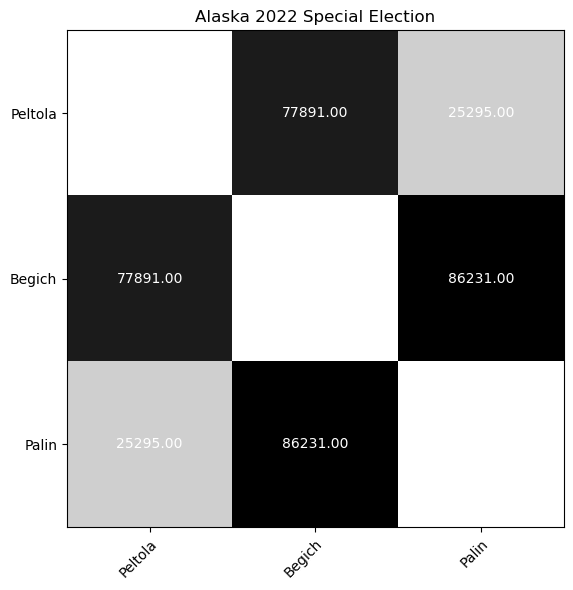

In [36]:
cand_order = ['Peltola', 'Begich', 'Palin']
mtx = get_cooccurence_matrix(output_ballots, ballot_counts, cand_order=cand_order)
plot_heatmap(mtx, row_labels=cand_order, col_labels=cand_order, title="Alaska 2022 Special Election")

In [23]:
def analyze_cvr_counts(cvr_data, contest_id=69):
    sessions = cvr_data.get("Sessions", [])

    total_sessions = len(sessions)
    total_cards = 0

    current_sessions = 0
    current_cards = 0

    # We’ll use this as our notion of "physical ballot"
    current_ballot_keys = set()

    # For contest-level stats
    ballots_with_contest = set()
    ballots_with_contest_and_vote = set()
    ballots_with_contest_outstack = set()

    cards_with_contest = 0
    cards_with_contest_and_vote = 0
    cards_with_contest_outstack = 0

    # Optional: count OutstackConditionIds to see what’s going on
    outstack_counter = Counter()

    for session in sessions:
        tabulator_id = session.get("TabulatorId")
        batch_id = session.get("BatchId")
        record_id = session.get("RecordId")
        ballot_key = (tabulator_id, batch_id, record_id)

        original = session.get("Original") or {}
        is_current = original.get("IsCurrent", True)
        cards = original.get("Cards", [])

        total_cards += len(cards)

        if not is_current:
            # Skip non-current versions when approximating “ballots that counted”
            continue

        current_sessions += 1
        current_cards += len(cards)
        current_ballot_keys.add(ballot_key)

        # Look for the contest of interest on each card
        ballot_has_contest = False
        ballot_has_contest_and_vote = False
        ballot_has_contest_outstack = False

        for card in cards:
            contests = card.get("Contests", [])
            for contest in contests:
                if contest.get("Id") != contest_id:
                    continue

                marks = contest.get("Marks", [])
                outstack_ids = contest.get("OutstackConditionIds", []) or []

                has_vote = any(m.get("IsVote", True) for m in marks)
                is_outstacked = len(outstack_ids) > 0

                # Per-card stats
                cards_with_contest += 1
                if has_vote:
                    cards_with_contest_and_vote += 1
                if is_outstacked:
                    cards_with_contest_outstack += 1
                    for oid in outstack_ids:
                        outstack_counter[oid] += 1

                # Per-ballot aggregate flags
                ballot_has_contest = True or ballot_has_contest
                ballot_has_contest_and_vote = has_vote or ballot_has_contest_and_vote
                ballot_has_contest_outstack = is_outstacked or ballot_has_contest_outstack

        # Update per-ballot sets
        if ballot_has_contest:
            ballots_with_contest.add(ballot_key)
        if ballot_has_contest_and_vote:
            ballots_with_contest_and_vote.add(ballot_key)
        if ballot_has_contest_outstack:
            ballots_with_contest_outstack.add(ballot_key)

    # Print summary
    print("=== RAW SESSION / CARD COUNTS ===")
    print(f"Total sessions (all versions): {total_sessions}")
    print(f"Total cards (all versions):   {total_cards}")
    print()
    print("=== CURRENT BALLOTS ONLY (Original['IsCurrent'] == True) ===")
    print(f"Current sessions:             {current_sessions}")
    print(f"Current cards:                {current_cards}")
    print(f"Unique current ballot keys:   {len(current_ballot_keys)}")
    print()
    print(f"=== CONTEST {contest_id} (on CURRENT ballots only) ===")
    print(f"Ballots with contest present:           {len(ballots_with_contest)}")
    print(f"Ballots with contest and a vote:        {len(ballots_with_contest_and_vote)}")
    print(f"Ballots with contest and outstacked:    {len(ballots_with_contest_outstack)}")
    print()
    print(f"Cards with contest present:             {cards_with_contest}")
    print(f"Cards with contest and a vote:          {cards_with_contest_and_vote}")
    print(f"Cards with contest and outstacked:      {cards_with_contest_outstack}")
    print()
    print("Most common OutstackConditionIds for this contest:")
    for oid, count in outstack_counter.most_common():
        print(f"  OutstackConditionId {oid}: {count} occurrences")


analyze_cvr_counts(alaska_cvr, contest_id=69)


=== RAW SESSION / CARD COUNTS ===
Total sessions (all versions): 192289
Total cards (all versions):   192289

=== CURRENT BALLOTS ONLY (Original['IsCurrent'] == True) ===
Current sessions:             192117
Current cards:                192117
Unique current ballot keys:   192117

=== CONTEST 69 (on CURRENT ballots only) ===
Ballots with contest present:           192117
Ballots with contest and a vote:        188339
Ballots with contest and outstacked:    178784

Cards with contest present:             192117
Cards with contest and a vote:          188339
Cards with contest and outstacked:      178784

Most common OutstackConditionIds for this contest:
  OutstackConditionId 14: 171346 occurrences
  OutstackConditionId 11: 5544 occurrences
  OutstackConditionId 13: 2775 occurrences
